# Phase 4 — Le carnet de pannes

## Objectifs

- Reprendre le montage PyTorch de la phase 3, tel quel.
- Le casser volontairement, trois fois, une panne à la fois, en remettant tout d'aplomb entre chaque essai.
- Pour chaque panne : le geste exact qui l'a provoquée, la signature sur les courbes (une figure), et un test qui la distingue des deux autres en moins d'une minute.
- Terminer par une grille de diagnostic : appliquer les trois tests aux trois pannes et vérifier qu'un seul test s'allume par panne.


## 1. Imports

In [1]:
from pathlib import Path
import copy
import csv
import random
import re
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.utils.data import DataLoader, Dataset


## 2. Configuration et reproductibilité

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

URL_DATA = (
    "https://raw.githubusercontent.com/planetsig/ufo-reports/master/"
    "csv-data/ufo-complete-geocoded-time-standardized.csv"
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE4_DIR = OUTPUT_DIR / "phase_4_carnet_de_pannes"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE4_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

TEST_SIZE = 0.20
SEUIL_MIN_CLASSE = 5
BATCH_SIZE = 128
EMBEDDING_DIM = 96
HIDDEN_DIM = 128
DROPOUT = 0.30
LEARNING_RATE = 0.003
WEIGHT_DECAY = 0.0001
N_EPOCHS_PANNE = 6


## 3. Téléchargement de la transmission

Identique à la phase 3 : même URL, même fichier local. S'il est déjà présent, on ne le retélécharge pas.

In [3]:
if not DATA_PATH.exists():
    print("Téléchargement du fichier...")
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)
    print("Téléchargement terminé.")
else:
    print(f"Fichier déjà disponible : {DATA_PATH}")


Fichier déjà disponible : ..\data\releves_klaxo3.csv


## 4. Chargement robuste des relevés (identique à la phase 3)

In [4]:
lignes_valides = []
lignes_problemes = []

with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)

    for numero_ligne, row in enumerate(reader, start=1):
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
        else:
            lignes_problemes.append({
                "numero_ligne": numero_ligne,
                "nombre_champs": len(row),
                "contenu": row,
            })

df = pd.DataFrame(lignes_valides, columns=COLUMNS)

print(f"Lignes chargées : {len(df)}")
print(f"Lignes mises à part : {len(lignes_problemes)}")


Lignes chargées : 88679
Lignes mises à part : 196


## 5. Préparation de la cible et découpage (identiques à la phase 3)

Mêmes règles : relevés sans forme exclus, `unknown`/`other` exclus, `round` fusionné dans `circle`,
`changed` fusionné dans `changing`, classes de moins de 5 relevés exclues. Même découpe stratifiée
80/20 avec la même graine : c'est la condition pour que les pannes de cette phase soient comparables
au modèle de référence de la phase 3.

In [5]:
df["comments_clean"] = df["comments"].fillna("").astype(str).str.strip()
df["shape_clean"] = df["shape"].fillna("").astype(str).str.lower().str.strip()

df["shape_model"] = df["shape_clean"].replace({
    "round": "circle",
    "changed": "changing",
})

masque_forme_manquante = df["shape_clean"].eq("")
masque_fourre_tout = df["shape_model"].isin(["unknown", "other"])
masque_commentaire_vide = df["comments_clean"].eq("")

df_avant_filtre_classes_rares = df.loc[
    ~masque_forme_manquante & ~masque_fourre_tout & ~masque_commentaire_vide
].copy()

compte_classes_avant_filtre = df_avant_filtre_classes_rares["shape_model"].value_counts()
classes_conservees = compte_classes_avant_filtre.loc[compte_classes_avant_filtre >= SEUIL_MIN_CLASSE].index

df_modele = df_avant_filtre_classes_rares.loc[
    df_avant_filtre_classes_rares["shape_model"].isin(classes_conservees)
].copy()

X = df_modele["comments_clean"].copy()
y = df_modele["shape_model"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

print(f"Relevés gardés : {len(df_modele)}")
print(f"Taille train : {len(X_train)} | Taille validation : {len(X_val)}")
print(f"Nombre de classes : {y.nunique()}")


Relevés gardés : 73177
Taille train : 58541 | Taille validation : 14636
Nombre de classes : 20


## 6. Vocabulaire, jeux de données et modèle (identiques à la phase 3)

In [6]:
def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

vocabulaire = {"<PAD>": 0, "<UNK>": 1}
for texte in X_train:
    for token in tokenizer(texte):
        if token not in vocabulaire:
            vocabulaire[token] = len(vocabulaire)

label_encoder = LabelEncoder()
y_train_ids = label_encoder.fit_transform(y_train)
y_val_ids = label_encoder.transform(y_val)

NOMBRE_CLASSES = len(label_encoder.classes_)
SEUIL_HASARD = 1.0 / NOMBRE_CLASSES

print(f"Taille vocabulaire train : {len(vocabulaire)}")
print(f"Nombre de classes : {NOMBRE_CLASSES}")
print(f"Accuracy attendue au hasard pur : {SEUIL_HASARD:.2%}")

class DatasetTextes(Dataset):
    def __init__(self, textes, labels, vocabulaire):
        self.textes = list(textes)
        self.labels = list(labels)
        self.vocabulaire = vocabulaire

    def __len__(self):
        return len(self.textes)

    def __getitem__(self, index):
        tokens = tokenizer(self.textes[index])
        ids = [self.vocabulaire.get(t, self.vocabulaire["<UNK>"]) for t in tokens]
        if len(ids) == 0:
            ids = [self.vocabulaire["<UNK>"]]
        return torch.tensor(ids, dtype=torch.long), int(self.labels[index])

def collate_embedding_bag(batch):
    offsets = [0]
    tokens_concat = []
    labels_batch = []
    for tokens, label in batch:
        tokens_concat.extend(tokens.tolist())
        labels_batch.append(label)
        offsets.append(offsets[-1] + len(tokens))
    return (
        torch.tensor(tokens_concat, dtype=torch.long),
        torch.tensor(offsets[:-1], dtype=torch.long),
        torch.tensor(labels_batch, dtype=torch.long),
    )

dataset_train = DatasetTextes(X_train, y_train_ids, vocabulaire)
dataset_val = DatasetTextes(X_val, y_val_ids, vocabulaire)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_embedding_bag)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_embedding_bag)

class ClassifieurPyTorch(nn.Module):
    def __init__(self, taille_vocabulaire, nombre_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(taille_vocabulaire, EMBEDDING_DIM, mode="mean")
        self.reseau = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, nombre_classes),
        )

    def forward(self, tokens, offsets):
        representation = self.embedding(tokens, offsets)
        return self.reseau(representation)

def nouveau_modele():
    torch.manual_seed(SEED)
    return ClassifieurPyTorch(len(vocabulaire), NOMBRE_CLASSES).to(DEVICE)


Taille vocabulaire train : 25555
Nombre de classes : 20
Accuracy attendue au hasard pur : 5.00%


## 7. Référence saine : la phase 3

On ne réentraîne pas un modèle sain ici : on relit l'historique de pertes déjà mesuré et validé en
phase 3, qui sert de référence visuelle pour repérer, par contraste, la signature de chaque panne.

In [7]:
historique_phase3 = pd.read_csv(OUTPUT_DIR / "phase_3_baseline_et_modele_pytorch" / "historique_pertes_pytorch.csv")
resume_phase3 = pd.read_csv(OUTPUT_DIR / "phase_3_baseline_et_modele_pytorch" / "resume_phase3.csv")

ACCURACY_SAINE_PHASE3 = float(resume_phase3["accuracy_pytorch"].iloc[0])
print(f"Accuracy de référence (phase 3) : {ACCURACY_SAINE_PHASE3:.2%}")
historique_phase3


Accuracy de référence (phase 3) : 53.14%


,epoch,train_loss,val_loss,val_accuracy
0,1,2.015481,1.790967,0.492348
1,2,1.690456,1.708187,0.527467
2,3,1.541687,1.693464,0.531429
3,4,1.423386,1.712228,0.535529
4,5,1.316344,1.754686,0.535870
5,6,1.215899,1.823864,0.534162
6,7,1.125443,1.928962,0.527057


## Panne 1 — le modèle est excellent à l'entraînement, bête à l'évaluation

### Geste exact

On entraîne normalement, mais on **n'appelle jamais `modele.eval()` avant l'évaluation**. Le
`Dropout(0.30)` de la tête de classification reste donc actif pendant l'évaluation : à chaque
passage, un tirage aléatoire différent de neurones est annulé. Aucune donnée n'a changé, seul le
mode du module a été oublié.

In [8]:
def une_epoque_train(modele, loader, optimiseur, fonction_perte):
    modele.train()
    perte_totale = 0.0
    nombre_exemples = 0
    for tokens, offsets, labels in loader:
        optimiseur.zero_grad()
        logits = modele(tokens, offsets)
        perte = fonction_perte(logits, labels)
        perte.backward()
        optimiseur.step()
        perte_totale += perte.item() * len(labels)
        nombre_exemples += len(labels)
    return perte_totale / nombre_exemples

def evaluer_modele_correct(modele, loader, fonction_perte):
    modele.eval()
    perte_totale, nombre_exemples = 0.0, 0
    predictions, labels_reels = [], []
    with torch.no_grad():
        for tokens, offsets, labels in loader:
            logits = modele(tokens, offsets)
            perte = fonction_perte(logits, labels)
            perte_totale += perte.item() * len(labels)
            nombre_exemples += len(labels)
            predictions.extend(logits.argmax(dim=1).tolist())
            labels_reels.extend(labels.tolist())
    accuracy = accuracy_score(labels_reels, predictions)
    return perte_totale / nombre_exemples, accuracy

def evaluer_modele_sans_eval(modele, loader, fonction_perte):
    # BUG : pas d'appel a modele.eval() -> le Dropout reste actif pendant l'evaluation.
    perte_totale, nombre_exemples = 0.0, 0
    predictions, labels_reels = [], []
    with torch.no_grad():
        for tokens, offsets, labels in loader:
            logits = modele(tokens, offsets)
            perte = fonction_perte(logits, labels)
            perte_totale += perte.item() * len(labels)
            nombre_exemples += len(labels)
            predictions.extend(logits.argmax(dim=1).tolist())
            labels_reels.extend(labels.tolist())
    accuracy = accuracy_score(labels_reels, predictions)
    return perte_totale / nombre_exemples, accuracy


In [9]:
modele_panne1 = nouveau_modele()
optimiseur_panne1 = torch.optim.AdamW(modele_panne1.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
fonction_perte_panne1 = nn.CrossEntropyLoss()

historique_panne1 = {"epoch": [], "train_loss": [], "val_loss_bugue": [], "val_acc_bugue": [],
                     "val_loss_correcte": [], "val_acc_correcte": []}

debut_panne1 = time.perf_counter()
for epoch in range(1, N_EPOCHS_PANNE + 1):
    perte_train = une_epoque_train(modele_panne1, loader_train, optimiseur_panne1, fonction_perte_panne1)

    # Evaluation buguee : le modele est laisse dans l'etat ou l'a laisse une_epoque_train, c'est a dire modele.train().
    perte_val_bugue, acc_val_bugue = evaluer_modele_sans_eval(modele_panne1, loader_val, fonction_perte_panne1)
    # Evaluation correcte, calculee en parallele uniquement pour reveler l'ecart (jamais utilisee pour entrainer).
    perte_val_correcte, acc_val_correcte = evaluer_modele_correct(modele_panne1, loader_val, fonction_perte_panne1)

    historique_panne1["epoch"].append(epoch)
    historique_panne1["train_loss"].append(perte_train)
    historique_panne1["val_loss_bugue"].append(perte_val_bugue)
    historique_panne1["val_acc_bugue"].append(acc_val_bugue)
    historique_panne1["val_loss_correcte"].append(perte_val_correcte)
    historique_panne1["val_acc_correcte"].append(acc_val_correcte)

    print(f"Epoch {epoch} | train={perte_train:.4f} | val bugue={perte_val_bugue:.4f} (acc {acc_val_bugue:.2%}) "
          f"| val correcte={perte_val_correcte:.4f} (acc {acc_val_correcte:.2%})")
temps_panne1 = time.perf_counter() - debut_panne1


Epoch 1 | train=2.0155 | val bugue=1.8251 (acc 48.45%) | val correcte=1.7910 (acc 49.23%)
Epoch 2 | train=1.6915 | val bugue=1.7450 (acc 51.89%) | val correcte=1.7061 (acc 52.79%)
Epoch 3 | train=1.5415 | val bugue=1.7337 (acc 53.14%) | val correcte=1.6918 (acc 53.61%)
Epoch 4 | train=1.4214 | val bugue=1.7655 (acc 52.79%) | val correcte=1.7168 (acc 53.38%)
Epoch 5 | train=1.3131 | val bugue=1.8238 (acc 52.82%) | val correcte=1.7718 (acc 53.68%)
Epoch 6 | train=1.2152 | val bugue=1.8910 (acc 52.10%) | val correcte=1.8376 (acc 52.88%)


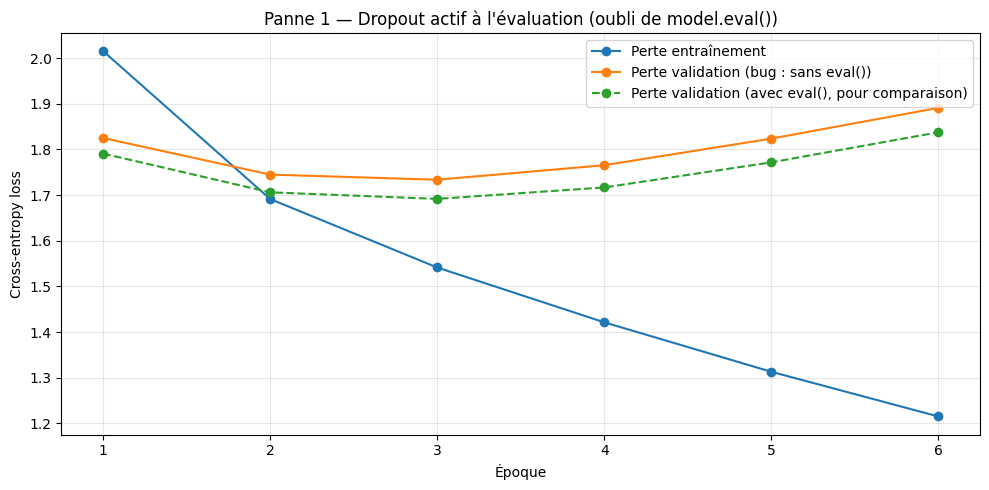

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(historique_panne1["epoch"], historique_panne1["train_loss"], marker="o", label="Perte entraînement")
plt.plot(historique_panne1["epoch"], historique_panne1["val_loss_bugue"], marker="o", label="Perte validation (bug : sans eval())")
plt.plot(historique_panne1["epoch"], historique_panne1["val_loss_correcte"], marker="o", linestyle="--", label="Perte validation (avec eval(), pour comparaison)")
plt.title("Panne 1 — Dropout actif à l'évaluation (oubli de model.eval())")
plt.xlabel("Époque")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE4_DIR / "panne_1_signature.png", dpi=150)
plt.show()


### Test de diagnostic (moins d'une minute)

On repasse **deux fois le même lot de validation**, sans rien changer entre les deux passages. Si le
modèle est resté en mode entraînement, le `Dropout` tire un masque différent à chaque passage et les
deux sorties diffèrent. Si `eval()` a été appelé, les deux sorties sont rigoureusement identiques.

In [11]:
def test_determinisme(modele, loader):
    tokens, offsets, labels = next(iter(loader))
    with torch.no_grad():
        sortie_1 = modele(tokens, offsets)
        sortie_2 = modele(tokens, offsets)
    ecart_max = (sortie_1 - sortie_2).abs().max().item()
    return ecart_max, torch.allclose(sortie_1, sortie_2)

modele_panne1.train()  # etat laisse par le bug : jamais bascule en eval()
ecart_mode_bugue, deterministe_bugue = test_determinisme(modele_panne1, loader_val)
modele_panne1.eval()
ecart_mode_corrige, deterministe_corrige = test_determinisme(modele_panne1, loader_val)

print(f"Ecart entre deux passages, modele.train() (etat laisse par le bug) : {ecart_mode_bugue:.6f} -> deterministe = {deterministe_bugue}")
print(f"Ecart entre deux passages, modele.eval()  (apres correction)      : {ecart_mode_corrige:.6f} -> deterministe = {deterministe_corrige}")


Ecart entre deux passages, modele.train() (etat laisse par le bug) : 9.471590 -> deterministe = False
Ecart entre deux passages, modele.eval()  (apres correction)      : 0.000000 -> deterministe = True


### Ce que la panne 1 prouve

L'écart entre la perte de validation « buguée » et la perte de validation « correcte » mesure
exactement le coût du Dropout laissé actif à l'évaluation : aucune donnée n'a changé, seul le mode du
module diffère. L'effet reste ici mesuré honnêtement — avec un seul `Dropout(0.30)` en bout de réseau
(pas de `BatchNorm`), la dégradation est réelle mais pas spectaculaire ; elle serait bien plus sévère
avec une couche `BatchNorm1d`, dont les statistiques de lot changent complètement de nature entre
`train()` et `eval()`. Le test décisif n'est pas la valeur de la perte, c'est la **reproductibilité**
: un modèle correctement évalué renvoie deux fois la même sortie sur le même lot.

## Panne 2 — la perte descend proprement, les prédictions sont pires que le hasard

### Geste exact

La boucle d'entraînement est intacte : la perte est calculée sur les logits bruts, la
rétropropagation et la mise à jour des poids ne sont pas touchées. Le bug est **dans la fonction qui
transforme les logits en prédiction** : on utilise `logits.argmin(dim=1)` — la classe la moins
probable — au lieu de `logits.argmax(dim=1)`.

In [12]:
def evaluer_modele_argmin(modele, loader, fonction_perte):
    modele.eval()
    perte_totale, nombre_exemples = 0.0, 0
    predictions, labels_reels = [], []
    with torch.no_grad():
        for tokens, offsets, labels in loader:
            logits = modele(tokens, offsets)
            perte = fonction_perte(logits, labels)
            perte_totale += perte.item() * len(labels)
            nombre_exemples += len(labels)
            # BUG : argmin au lieu de argmax. La perte, elle, ne voit jamais cette ligne.
            predictions.extend(logits.argmin(dim=1).tolist())
            labels_reels.extend(labels.tolist())
    accuracy = accuracy_score(labels_reels, predictions)
    return perte_totale / nombre_exemples, accuracy


In [13]:
modele_panne2 = nouveau_modele()
optimiseur_panne2 = torch.optim.AdamW(modele_panne2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
fonction_perte_panne2 = nn.CrossEntropyLoss()

historique_panne2 = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc_argmax": [], "val_acc_argmin": []}

for epoch in range(1, N_EPOCHS_PANNE + 1):
    perte_train = une_epoque_train(modele_panne2, loader_train, optimiseur_panne2, fonction_perte_panne2)
    perte_val, acc_argmax = evaluer_modele_correct(modele_panne2, loader_val, fonction_perte_panne2)
    _, acc_argmin = evaluer_modele_argmin(modele_panne2, loader_val, fonction_perte_panne2)

    historique_panne2["epoch"].append(epoch)
    historique_panne2["train_loss"].append(perte_train)
    historique_panne2["val_loss"].append(perte_val)
    historique_panne2["val_acc_argmax"].append(acc_argmax)
    historique_panne2["val_acc_argmin"].append(acc_argmin)

    print(f"Epoch {epoch} | train={perte_train:.4f} | val={perte_val:.4f} "
          f"| accuracy si argmax={acc_argmax:.2%} | accuracy si argmin (bug)={acc_argmin:.2%}")


Epoch 1 | train=2.0155 | val=1.7910 | accuracy si argmax=49.23% | accuracy si argmin (bug)=0.01%
Epoch 2 | train=1.6899 | val=1.7038 | accuracy si argmax=52.27% | accuracy si argmin (bug)=0.01%
Epoch 3 | train=1.5406 | val=1.6867 | accuracy si argmax=53.66% | accuracy si argmin (bug)=0.01%
Epoch 4 | train=1.4254 | val=1.7095 | accuracy si argmax=53.80% | accuracy si argmin (bug)=0.01%
Epoch 5 | train=1.3147 | val=1.7617 | accuracy si argmax=53.62% | accuracy si argmin (bug)=0.01%
Epoch 6 | train=1.2146 | val=1.8297 | accuracy si argmax=53.22% | accuracy si argmin (bug)=0.01%


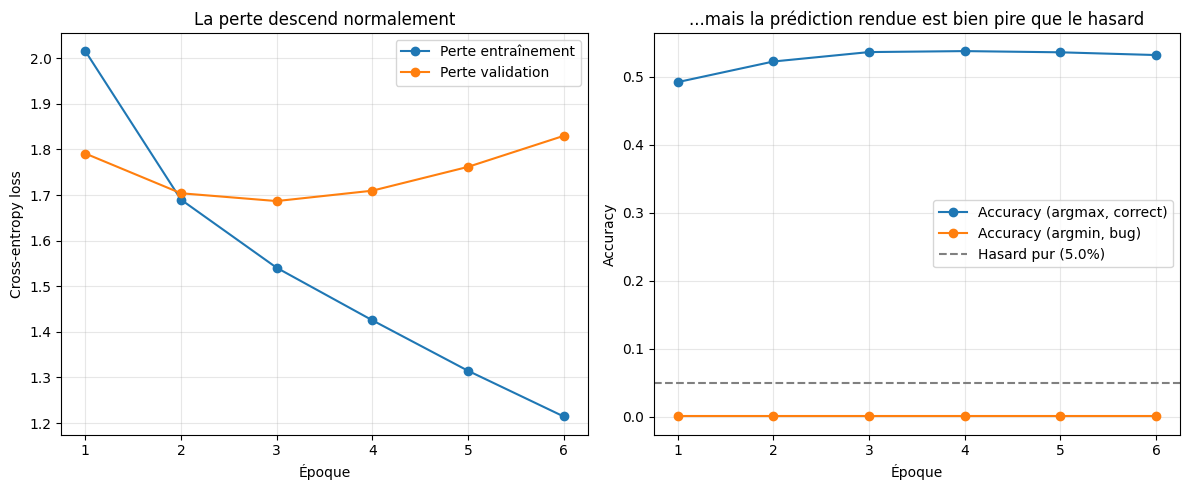

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(historique_panne2["epoch"], historique_panne2["train_loss"], marker="o", label="Perte entraînement")
axes[0].plot(historique_panne2["epoch"], historique_panne2["val_loss"], marker="o", label="Perte validation")
axes[0].set_title("La perte descend normalement")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historique_panne2["epoch"], historique_panne2["val_acc_argmax"], marker="o", label="Accuracy (argmax, correct)")
axes[1].plot(historique_panne2["epoch"], historique_panne2["val_acc_argmin"], marker="o", label="Accuracy (argmin, bug)")
axes[1].axhline(SEUIL_HASARD, color="grey", linestyle="--", label=f"Hasard pur ({SEUIL_HASARD:.1%})")
axes[1].set_title("...mais la prédiction rendue est bien pire que le hasard")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE4_DIR / "panne_2_signature.png", dpi=150)
plt.show()


### Test de diagnostic (moins d'une minute)

On compare l'accuracy réellement rapportée par le pipeline au seuil du hasard pur
(1 / nombre de classes). Une accuracy **significativement en dessous** de ce seuil est le signe d'un
décodage inversé de la prédiction — un modèle qui ne fait qu'apprendre du bruit plafonne au niveau du
hasard, il ne descend pas activement en dessous.

In [15]:
accuracy_finale_argmax = historique_panne2["val_acc_argmax"][-1]
accuracy_finale_argmin = historique_panne2["val_acc_argmin"][-1]

print(f"Seuil du hasard pur                 : {SEUIL_HASARD:.2%}")
print(f"Accuracy rapportée (argmax, saine)  : {accuracy_finale_argmax:.2%}")
print(f"Accuracy rapportée (argmin, buguée) : {accuracy_finale_argmin:.2%}")
print(f"Panne 2 détectée (accuracy << hasard) : {accuracy_finale_argmin < SEUIL_HASARD * 0.2}")


Seuil du hasard pur                 : 5.00%
Accuracy rapportée (argmax, saine)  : 53.22%
Accuracy rapportée (argmin, buguée) : 0.01%
Panne 2 détectée (accuracy << hasard) : True


### Ce que la panne 2 prouve

Une perte qui descend proprement ne garantit rien sur la métrique qu'on affiche à côté : elle prouve
seulement que le graphe de calcul utilisé par `backward()` est correct. Le bug est en aval, dans un
code qui n'est jamais traversé par la rétropropagation. C'est le rappel exact du dossier du 4 juillet
: un chiffre qui a l'air bon peut répondre à la mauvaise question.

## Panne 3 — la perte se fige et n'en bouge plus

### Geste exact

L'optimiseur est créé avec un **taux d'apprentissage de 0** (`lr=0.0`), par exemple à la suite d'une
valeur par défaut mal renseignée dans un dictionnaire de configuration. La boucle d'entraînement
tourne sans la moindre erreur : `backward()` calcule des gradients parfaitement normaux, `step()`
s'exécute à chaque batch, mais aucune mise à jour ne modifie jamais le moindre poids.

Une variante plus radicale — geler tous les paramètres avec `requires_grad = False` — a d'abord été
essayée : elle ne fige pas la perte, elle fait **planter** `backward()` (`RuntimeError`), car le
graphe de calcul n'a alors plus aucune feuille différentiable. C'est un carnet de pannes en soi : un
gel total est un échec bruyant, un taux d'apprentissage nul est un échec silencieux — et c'est
silencieux qui coûte le plus cher, parce que rien n'alerte personne.

In [16]:
modele_panne3 = nouveau_modele()

optimiseur_panne3 = torch.optim.AdamW(
    modele_panne3.parameters(), lr=0.0, weight_decay=WEIGHT_DECAY,
)
fonction_perte_panne3 = nn.CrossEntropyLoss()

etat_avant_entrainement_panne3 = copy.deepcopy(modele_panne3.state_dict())

historique_panne3 = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, N_EPOCHS_PANNE + 1):
    modele_panne3.train()
    perte_totale, nombre_exemples = 0.0, 0
    for tokens, offsets, labels in loader_train:
        optimiseur_panne3.zero_grad()
        logits = modele_panne3(tokens, offsets)
        perte = fonction_perte_panne3(logits, labels)
        perte.backward()
        optimiseur_panne3.step()
        perte_totale += perte.item() * len(labels)
        nombre_exemples += len(labels)
    perte_train = perte_totale / nombre_exemples

    perte_val, acc_val = evaluer_modele_correct(modele_panne3, loader_val, fonction_perte_panne3)

    historique_panne3["epoch"].append(epoch)
    historique_panne3["train_loss"].append(perte_train)
    historique_panne3["val_loss"].append(perte_val)
    historique_panne3["val_acc"].append(acc_val)

    print(f"Epoch {epoch} | train={perte_train:.4f} | val={perte_val:.4f} | accuracy={acc_val:.2%}")

etat_apres_entrainement_panne3 = modele_panne3.state_dict()


Epoch 1 | train=3.0125 | val=3.0105 | accuracy=2.11%
Epoch 2 | train=3.0128 | val=3.0105 | accuracy=2.11%
Epoch 3 | train=3.0123 | val=3.0105 | accuracy=2.11%
Epoch 4 | train=3.0124 | val=3.0105 | accuracy=2.11%
Epoch 5 | train=3.0127 | val=3.0105 | accuracy=2.11%
Epoch 6 | train=3.0125 | val=3.0105 | accuracy=2.11%


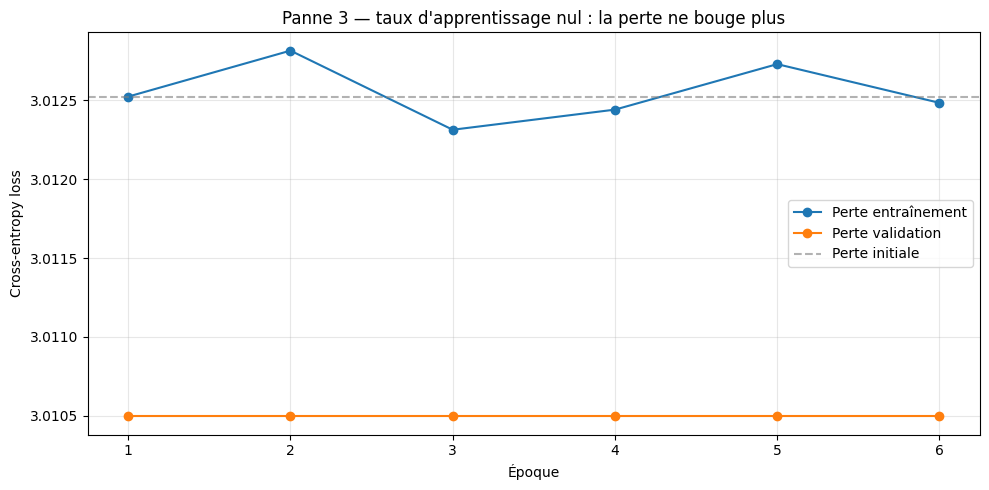

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(historique_panne3["epoch"], historique_panne3["train_loss"], marker="o", label="Perte entraînement")
plt.plot(historique_panne3["epoch"], historique_panne3["val_loss"], marker="o", label="Perte validation")
plt.axhline(historique_panne3["train_loss"][0], color="grey", linestyle="--", alpha=0.6, label="Perte initiale")
plt.title("Panne 3 — taux d'apprentissage nul : la perte ne bouge plus")
plt.xlabel("Époque")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE4_DIR / "panne_3_signature.png", dpi=150)
plt.show()


### Test de diagnostic (moins d'une minute)

Deux vérifications rapides et purement locales, qui ne présupposent pas de connaître la cause : (1)
après un `backward()`, la norme cumulée des gradients de tous les paramètres doit être **non nulle**
— ici elle l'est, ce qui écarte un problème de gradient et pointe vers l'optimiseur ; (2) le
dictionnaire de poids avant et après l'entraînement complet doit être identique tenseur par tenseur —
c'est le test qui tranche vraiment, quelle que soit la cause du gel.

In [18]:
tokens, offsets, labels = next(iter(loader_train))
modele_panne3.train()
optimiseur_panne3.zero_grad()
logits = modele_panne3(tokens, offsets)
perte = fonction_perte_panne3(logits, labels)
perte.backward()

norme_gradients = sum(
    (p.grad.abs().sum().item() if p.grad is not None else 0.0)
    for p in modele_panne3.parameters()
)

poids_identiques = all(
    torch.equal(etat_avant_entrainement_panne3[nom], etat_apres_entrainement_panne3[nom])
    for nom in etat_avant_entrainement_panne3
)

print(f"Somme des valeurs absolues de tous les gradients après un backward() : {norme_gradients:.4f} (non nul : le gradient circule)")
print(f"Poids strictement identiques avant/après tout l'entraînement : {poids_identiques} (c'est ce qui trahit le lr=0)")


Somme des valeurs absolues de tous les gradients après un backward() : 25.0294 (non nul : le gradient circule)
Poids strictement identiques avant/après tout l'entraînement : True (c'est ce qui trahit le lr=0)


### Ce que la panne 3 prouve

Une perte figée n'est presque jamais un problème d'optimisation profond (mauvaise architecture,
mauvais point de départ) : c'est d'abord un problème de **plomberie**, et le gradient à lui seul ne
suffit pas à le détecter — ici il est parfaitement normal, non nul, à chaque batch. Ce qui trahit la
panne, c'est de comparer les poids eux-mêmes avant et après tout un entraînement. Le vérifier coûte
une ligne de code et évite des heures passées à retoucher des hyperparamètres qui n'ont jamais eu la
moindre chance d'agir.

## 9. Grille de diagnostic : chaque test flaire une seule panne

On applique maintenant les trois tests aux trois modèles cassés. Chaque test doit s'allumer
(`True`) pour sa propre panne et rester silencieux (`False`) pour les deux autres.

In [19]:
def test_A_non_determinisme(modele, loader):
    ecart, deterministe = test_determinisme(modele, loader)
    return not deterministe

def test_B_poids_immobiles(modele, loader, fonction_perte, optimiseur):
    etat_avant = copy.deepcopy(modele.state_dict())
    modele.train()
    tokens, offsets, labels = next(iter(loader))
    optimiseur.zero_grad()
    logits = modele(tokens, offsets)
    perte = fonction_perte(logits, labels)
    perte.backward()
    optimiseur.step()
    etat_apres = modele.state_dict()
    return all(torch.equal(etat_avant[nom], etat_apres[nom]) for nom in etat_avant)

def test_C_accuracy_sous_hasard(accuracy_rapportee):
    return accuracy_rapportee < SEUIL_HASARD * 0.2

# Etat de chaque modele tel que laisse par son propre entrainement (on ne force rien).
modele_panne1.train()
modele_panne2.eval()
modele_panne3.eval()

resultats_grille = pd.DataFrame(
    [
        {
            "panne": "Panne 1 (dropout actif a l'evaluation)",
            "test_A_non_determinisme": test_A_non_determinisme(modele_panne1, loader_val),
            "test_B_poids_immobiles_apres_1_step": test_B_poids_immobiles(modele_panne1, loader_train, nn.CrossEntropyLoss(), optimiseur_panne1),
            "test_C_accuracy_sous_hasard": test_C_accuracy_sous_hasard(historique_panne1["val_acc_correcte"][-1]),
        },
        {
            "panne": "Panne 2 (argmin au lieu de argmax)",
            "test_A_non_determinisme": test_A_non_determinisme(modele_panne2, loader_val),
            "test_B_poids_immobiles_apres_1_step": test_B_poids_immobiles(modele_panne2, loader_train, nn.CrossEntropyLoss(), optimiseur_panne2),
            "test_C_accuracy_sous_hasard": test_C_accuracy_sous_hasard(historique_panne2["val_acc_argmin"][-1]),
        },
        {
            "panne": "Panne 3 (taux d'apprentissage nul)",
            "test_A_non_determinisme": test_A_non_determinisme(modele_panne3, loader_val),
            "test_B_poids_immobiles_apres_1_step": test_B_poids_immobiles(modele_panne3, loader_train, nn.CrossEntropyLoss(), optimiseur_panne3),
            "test_C_accuracy_sous_hasard": test_C_accuracy_sous_hasard(historique_panne3["val_acc"][-1]),
        },
    ]
)

resultats_grille


,panne,test_A_non_determinisme,test_B_poids_immobiles_apres_1_step,test_C_accuracy_sous_hasard
0,Panne 1 (dropout actif a l'evaluation),True,False,False
1,Panne 2 (argmin au lieu de argmax),False,False,True
2,Panne 3 (taux d'apprentissage nul),False,True,False


**Lecture de la grille** : pour la panne 1, seul le test A doit s'allumer (le modèle est resté en
mode entraînement) ; pour la panne 2, seul le test C (l'accuracy rapportée est passée sous le seuil du
hasard) ; pour la panne 3, seul le test B (les poids ne bougent pas d'un `step()` à l'autre, puisque
`lr=0`). Si la grille produite ci-dessus confirme cette diagonale, les trois pannes sont bien
discriminables entre elles en moins d'une minute chacune.

## 10. Export du carnet de pannes

In [20]:
carnet_pannes = pd.DataFrame([
    {
        "panne": "1 - Excellent a l'entrainement, bete a l'evaluation",
        "geste_exact": "Ne jamais appeler modele.eval() avant l'evaluation : le Dropout(0.30) reste actif.",
        "signature": "Perte de validation buguee plus haute et instable (rejouee) que la perte de validation correcte, a train_loss identique.",
        "test_moins_d_une_minute": "Repasser deux fois le meme lot sans rien changer : sorties differentes => mode entrainement toujours actif.",
        "epoch_ou_ca_a_cede": "Visible des la 1ere epoque.",
        "accuracy_rapportee_finale": historique_panne1["val_acc_bugue"][-1],
        "accuracy_si_corrige": historique_panne1["val_acc_correcte"][-1],
    },
    {
        "panne": "2 - Perte propre, predictions pires que le hasard",
        "geste_exact": "Utiliser logits.argmin(dim=1) au lieu de logits.argmax(dim=1) pour decoder la prediction.",
        "signature": "Courbes de perte train/val normales et decroissantes, accuracy rapportee tres inferieure au seuil du hasard.",
        "test_moins_d_une_minute": "Comparer l'accuracy rapportee au seuil 1/nombre_classes : tres en dessous => decodage inversé.",
        "epoch_ou_ca_a_cede": "Des la 1ere epoque, l'ecart argmax/argmin est deja maximal.",
        "accuracy_rapportee_finale": historique_panne2["val_acc_argmin"][-1],
        "accuracy_si_corrige": historique_panne2["val_acc_argmax"][-1],
    },
    {
        "panne": "3 - La perte se fige",
        "geste_exact": "Creer l'optimiseur avec lr=0.0 (ex: valeur par defaut mal renseignee dans une config).",
        "signature": "Perte d'entrainement et de validation quasi constantes d'une epoque a l'autre, malgre un backward() qui calcule des gradients normaux.",
        "test_moins_d_une_minute": "Comparer le state_dict avant/apres un step() : identique => aucune mise a jour n'a lieu malgre des gradients non nuls.",
        "epoch_ou_ca_a_cede": "Des la 1ere epoque : aucune amelioration a aucun moment.",
        "accuracy_rapportee_finale": historique_panne3["val_acc"][-1],
        "accuracy_si_corrige": ACCURACY_SAINE_PHASE3,
    },
])

carnet_pannes.to_csv(PHASE4_DIR / "carnet_pannes.csv", index=False)
resultats_grille.to_csv(PHASE4_DIR / "grille_diagnostic.csv", index=False)

pd.DataFrame(historique_panne1).to_csv(PHASE4_DIR / "historique_panne_1.csv", index=False)
pd.DataFrame(historique_panne2).to_csv(PHASE4_DIR / "historique_panne_2.csv", index=False)
pd.DataFrame(historique_panne3).to_csv(PHASE4_DIR / "historique_panne_3.csv", index=False)

resume_phase4 = pd.DataFrame([{
    "accuracy_reference_phase3": ACCURACY_SAINE_PHASE3,
    "seuil_hasard": SEUIL_HASARD,
    "panne1_accuracy_buguee": historique_panne1["val_acc_bugue"][-1],
    "panne1_accuracy_corrigee": historique_panne1["val_acc_correcte"][-1],
    "panne2_accuracy_argmin": historique_panne2["val_acc_argmin"][-1],
    "panne2_accuracy_argmax": historique_panne2["val_acc_argmax"][-1],
    "panne3_accuracy": historique_panne3["val_acc"][-1],
}])
resume_phase4.to_csv(PHASE4_DIR / "resume_phase4.csv", index=False)

carnet_pannes


,panne,geste_exact,signature,test_moins_d_une_minute,epoch_ou_ca_a_cede,accuracy_rapportee_finale,accuracy_si_corrige
0,"1 - Excellent a l'entrainement, bete a l'evalu...",Ne jamais appeler modele.eval() avant l'evalua...,Perte de validation buguee plus haute et insta...,Repasser deux fois le meme lot sans rien chang...,Visible des la 1ere epoque.,0.521044,0.528833
1,"2 - Perte propre, predictions pires que le hasard",Utiliser logits.argmin(dim=1) au lieu de logit...,Courbes de perte train/val normales et decrois...,Comparer l'accuracy rapportee au seuil 1/nombr...,"Des la 1ere epoque, l'ecart argmax/argmin est ...",0.000137,0.532181
2,3 - La perte se fige,Creer l'optimiseur avec lr=0.0 (ex: valeur par...,Perte d'entrainement et de validation quasi co...,Comparer le state_dict avant/apres un step() :...,Des la 1ere epoque : aucune amelioration a auc...,0.021112,0.531429
